# HF TDOA Analysis - Figures 13 & 14

This notebook uses the `hf_tdoa` library to analyze HF TDOA measurements and generate Figures 13 and 14.

In [1]:
import os
import datetime
import importlib
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [2]:
base_dir   = '../data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('../templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: N6RFM (EM12jw), Range: 407.3 km, Band: 7 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 39
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 39/39 [00:03<00:00,  9.77file/s, Chirps=10, Max Corr=4.61e+03]

✓ Completed chirp detection: 39 files processed, 390 total chirps found



## Find TDOAs

In [4]:
debug_TDOAs = False

# Find TDOAs for each propagation mode using the simplified API
# The mode configurations (filter limits, search limits, model coefficients, and plotting params)
# are now stored in hf_tdoa_lib.MODE_CONFIGS

# Process all three modes
for mode_string in ['2F2-1F2', '1F2-1E', '2F2-1E']:
    chirps = tdoa.find_TDOAs(chirps, mode_string=mode_string,
                            plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary with model coefficients and plotting parameters
tdoa_dct = tdoa.build_tdoa_config(chirps)

# Print calculated model coefficients for verification
print("Calculated TDOA Model Coefficients:")
print("=" * 60)
for set_name, params in tdoa_dct.items():
    slope, intercept = params['model_coeffs']
    mode_str = params['mode_string']
    print(f"{set_name:12s} ({mode_str:8s}): slope={slope:6.1f}, intercept={intercept:6.1f}")
print("=" * 60)
print()


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (2F2-1F2): 100%|██████████| 39/39 [00:13<00:00,  2.91file/s, Mean TDOA=1.65 ms]


✓ Completed processing 2F2-1F2: 39 files processed


Processing Mode: 1F2-1E
  Filter Limits:  2.5 - 30.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     5.0 - 12.0 Hz
  Set Name:       1F2-1E
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (1F2-1E): 100%|██████████| 39/39 [00:14<00:00,  2.75file/s, Mean TDOA=0.98 ms]


✓ Completed processing 1F2-1E: 39 files processed


Processing Mode: 2F2-1E
  Filter Limits:  20.0 - 30.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     22.0 - 30.0 Hz
  Set Name:       2F2-1E
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (2F2-1E): 100%|██████████| 39/39 [00:15<00:00,  2.54file/s, Mean TDOA=2.56 ms]


✓ Completed processing 2F2-1E: 39 files processed

Calculated TDOA Model Coefficients:
2F2-1F2      (2F2-1F2 ): slope= 141.0, intercept=  46.6
1F2-1E       (1F2-1E  ): slope= 181.3, intercept= 136.2
2F2-1E       (2F2-1E  ): slope=  79.3, intercept=  85.7



## Figure 13 - TDOA Measurements

Figure saved to: fig_13.jpg


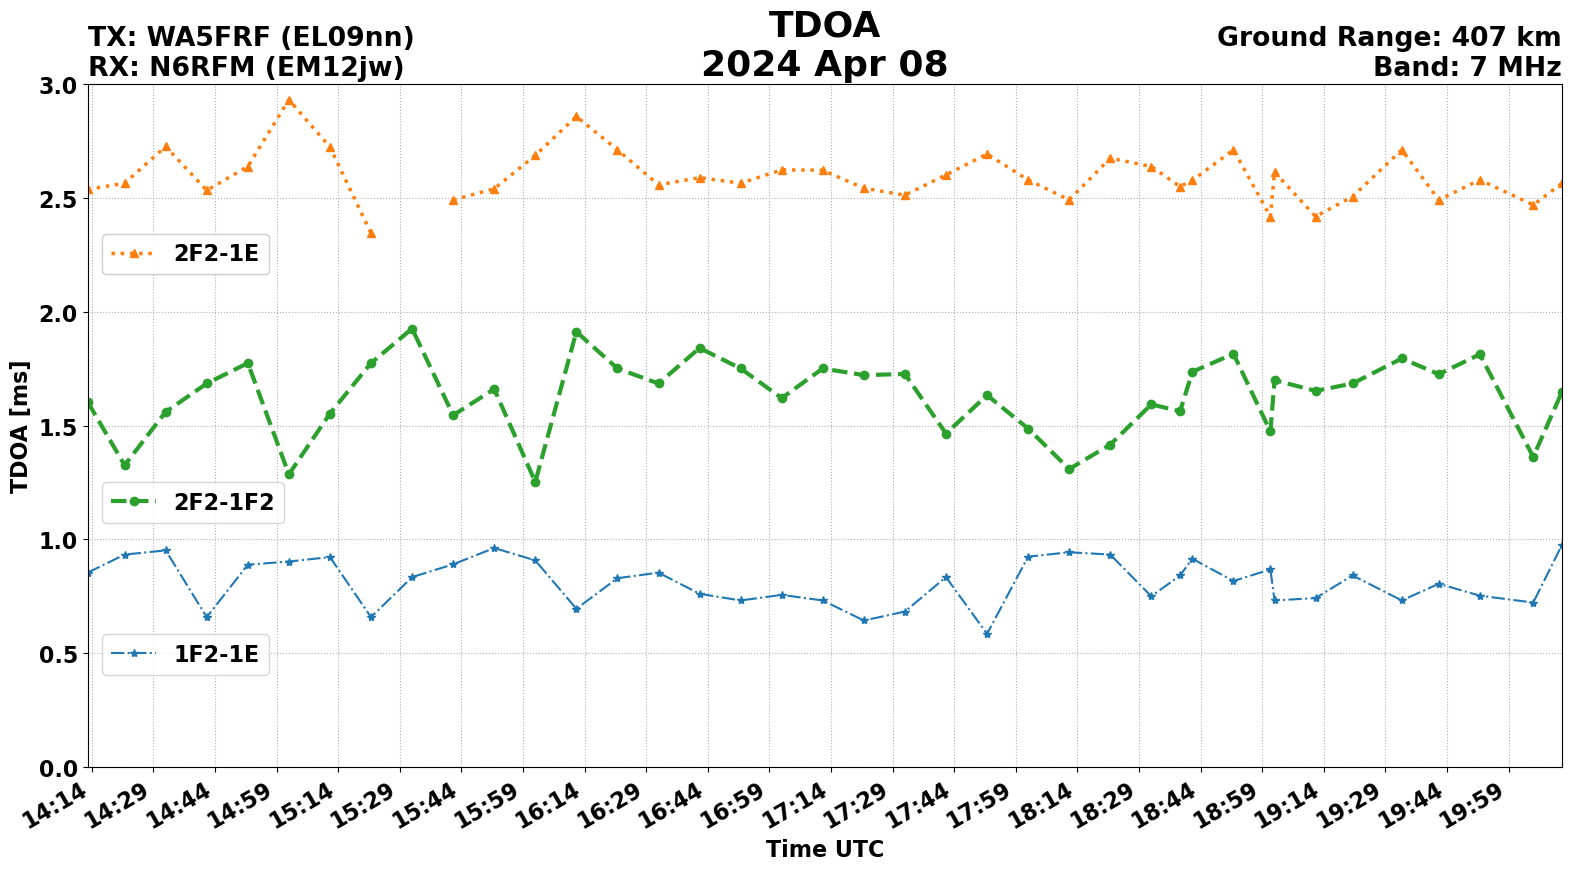

In [5]:
tdoa.plot_TDOAs(chirps, tdoa_dct, savefig='fig_13.jpg')

## Figure 14 - Layer Heights Comparison with Ionosonde

In [ ]:
# Set time limits for the plot
xlim = (datetime.datetime(2024, 4, 8, 14, 0), datetime.datetime(2024, 4, 8, 20, 30))

tdoa.plot_hmf2(chirps, tdoa_dct, xlim=xlim, ionosonde_dct=True, savefig='fig_14.jpg')

## Path Information

The `path_info` object provides convenient access to TX/RX coordinates and other path-related calculations.

In [7]:
# Access the path_info object stored when chirps were created
path_info = chirps.attrs['path_info']

# Display path information
print(f"Path Information:")
print(f"  {path_info}")
print()

# Get TX and RX coordinates from gridsquares
tx_lat, tx_lon = path_info.get_tx_latlon()
rx_lat, rx_lon = path_info.get_rx_latlon()
print(f"TX Location: {tx_lat:.3f}°N, {tx_lon:.3f}°E ({path_info.tx_grid})")
print(f"RX Location: {rx_lat:.3f}°N, {rx_lon:.3f}°E ({path_info.rx_grid})")
print()

# Calculate the great circle midpoint between TX and RX
mid_lat, mid_lon = path_info.get_midpoint()
print(f"Path Midpoint: {mid_lat:.3f}°N, {mid_lon:.3f}°E")
print()

# Calculate the azimuth from TX to RX
azimuth = path_info.get_path_azimuth()
print(f"Path Azimuth (TX→RX): {azimuth:.1f}°")
print()

Path Information:
  PathInfo(TX: WA5FRF (EL09nn), RX: N6RFM (EM12jw), Range: 407.3 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 32.938°N, -97.208°E (EM12jw)

Path Midpoint: 31.253°N, -98.057°E

Path Azimuth (TX→RX): 22.5°



## Figure 14 (Enhanced) - Layer Heights with Solar Elevation and Eclipse Obscuration

This version of Figure 14 includes overlays for Solar Elevation Angle and Eclipse Obscuration.
The solar coordinates are automatically calculated from the TX/RX path midpoint.

In [ ]:
# Use the path midpoint for solar calculations
solar_lat, solar_lon = path_info.get_midpoint()

# Set time limits for the plot
xlim = (datetime.datetime(2024, 4, 8, 14, 0), datetime.datetime(2024, 4, 8, 20, 30))

# Create enhanced plot with solar elevation and eclipse obscuration overlays
tdoa.plot_hmf2(chirps, tdoa_dct,
               xlim=xlim,
               solar_lat=solar_lat,
               solar_lon=solar_lon,
               overlay_solar_elevation=True,
               overlay_eclipse=True,
               ionosonde_dct=True)